In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
import re
import spacy
import seaborn as sns
import matplotlib.pyplot as plt 

from collections import defaultdict

## Téléchargement des données et preprocessing

In [2]:
data = pd.read_csv("data/metadonnees.csv")
data.head()

C:\Users\auran\AppData\Local\Temp\ipykernel_18456\3855839679.py:1: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/metadonnees.csv")


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;As...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,35,entre 30 et 39 ans,greffier de paix,conseiller municipal;conseiller général,non mentionné,non mentionné,combattant,non mentionné,non mentionné,oui
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur;président Coopérative élevage,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,non mentionné,non


In [3]:
data.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='object')

In [4]:
data["date"] = pd.to_datetime(data["date"])

data[["annee","mois","jour"]] = data["date"].apply(
    lambda x: pd.Series([x.year, x.month, x.day])
)
print("Nombre de professions par années :", data["annee"].value_counts().sort_index())

Nombre de professions par années : annee
1958    2774
1959       7
1962    2235
1965       8
1967    2871
1968    2872
1969       8
1973    3843
1974      13
1978    4830
1979       7
1981    3133
1986     740
1988    3551
1989      13
1993    5837
1995      11
1999      14
2002      18
2004      50
2007      13
2009      60
2012      12
2014      97
2019      13
Name: count, dtype: int64


In [5]:
# Export des professions de foi de l'année 1993
zip_path = "C:/Users/auran/OneDrive/Documents/ensae/3A/NLP/legislatives.zip"

docs = []

with zipfile.ZipFile(zip_path) as z:
    for file in z.namelist():
        if file.endswith(".txt"):
            with z.open(file) as f:
                text = f.read().decode("utf-8", errors="ignore")
                docs.append({"file": file, "text": text})

transcriptions = pd.DataFrame(docs)

transcriptions = transcriptions.assign(
    id=transcriptions["file"].str.extract(r'([^/]+)\.txt'),
    annee=transcriptions["file"].str.extract(r'text_files/(\d{4})')
)
transcriptions = transcriptions.drop(columns = ["file"])

transcriptions = transcriptions.merge(data[['id', 'titulaire-soutien']], on='id', how='left')


In [6]:
transcriptions.head()

,text,id,annee,titulaire-soutien
0,Département de Seine-Maritime - 12ème Circonsc...,EL196_L_1993_03_076_12_1_PF_01,1993,non mentionné
1,ELECTIONS LEGISLATIVES DU 21 MARS 1993\nREPUBL...,EL190_L_1993_03_024_02_1_PF_03,1993,non mentionné
2,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,EL190_L_1993_03_017_01_1_PF_07,1993,Parti de la loi naturelle
3,Sciences Po / fonds CEVIPOF\nENTENTE DES ECOLO...,EL192_L_1993_03_050_02_1_PF_03,1993,Verts;Génération écologie
4,Sciences Po / fonds CEVIPOF\nLes Verts Confédé...,EL196_L_1993_03_079_04_1_PF_03,1993,Génération écologie;Verts


In [7]:
len(pd.unique(transcriptions['titulaire-soutien']))

308

On cherche à étudier les différentes méthodes d'adresse des candidats par partis politiques. On ne dispose ici que d'une variable 'titulaire-soutien' qui encode 308 différents courants. On cherche donc à créer une variable plus synthétique regroupant les différents grands partis de l'époque. Le code qui suit peut éventuellement être encore affiné.

In [8]:
# Création d'une autre variable d'affiliation politique plus synthétique

def classifier_parti(etiquette_brute):
    if pd.isna(etiquette_brute) or etiquette_brute == 'nan':
        return np.nan
    
    texte = str(etiquette_brute).lower()
    
    sous_partis = [p.strip() for p in texte.split(';')]
    
    # Drapeaux (Flags) pour détecter les familles présentes
    is_ps = False
    is_udf_rpr = False
    is_centre = False
    is_eco = False
    is_extreme_droite = False
    is_extreme_gauche = False
    is_regionaliste = False
    is_sans_etiquette = False
    
    # Mots-clés par famille
    keywords = {
        'ps': ['parti socialiste', 'ps', 'gauche', 'mouvement des citoyens', 'socialistes', 'socialiste'],

        'rpr' : ['rassemblement pour la république', 'rassemblement pour la republique', 'rpr'],

        'udf' : ['union pour la démocratie française', 'union pour la democratie francaise', 'udf'],
        
        'centre': ['mouvement démocrate', 'modem', 'centriste', 'centre des démocrates sociaux', 
                   'nouveau centre', 'les centristes', 'agir', 'alliance centriste', 
                   'centre', 'mouvement des réformateurs'],
        
        'ecolo': ['vert', 'verts', 'écologie', 'ecolo', 'génération écologie', 'nature et animaux', 
                  'région verte', 'écologiste', 'biosphère', 'generation ecologie', 'écologie les verts',
                  'ecologie les verts', 'ecologie'],
        
        'extreme_droite': ['front national', 'fn', 'mouvement national', 'jeunesse nationaliste', 
                           'alsace d\'abord', 'identitaire', 'patriote', "trop d'immigrés la france aux français"],
        
        'extreme_gauche': ['lutte ouvrière', 'ligue communiste', 'npa', 'nouveau parti anticapitaliste',
                           'parti des travailleurs', 'trotskyste', 'alternative libertaire',
                           'parti communiste français', 'ligue communiste révolutionnaire', 'communistes',
                           'communiste'],
        
        'regionaliste': ['corsica', 'breton', 'occitan', 'alsacien', 'basque', 'euskal', 'unitat catalana',
                         'union démocratique bretonne', 'udb', 'autonomie', 'indépendantiste', 'abertzale',
                         'corse', 'corsa', 'eusko alkartasuna', 'esquerra republicana de catalunya'],
        
        'sans_etiquette': ['sans étiquette', 'divers', 'indépendant', 'apolitique', 'aucun parti', 
                           'non mentionné', 'non inscrit', 'hors des partis', 'société civile', 'libre', 'nan',
                           'sans parti politique', 'aucune formation politique']
    }
    # Analyse de chaque sous-parti
    for parti in sous_partis:
        # Vérification Gauche
        if any(k in parti for k in keywords['ps']):
            is_ps = True
        # Vérification Droite
        if any(k in parti for k in keywords['rpr']) or any(k in parti for k in keywords['udf']):
            is_udf_rpr = True
        # Vérification Centre
        if any(k in parti for k in keywords['centre']):
            is_centre = True
        # Vérification Écologie
        if any(k in parti for k in keywords['ecolo']):
            is_eco = True
        # Vérification Extrême Droite
        if any(k in parti for k in keywords['extreme_droite']):
            is_extreme_droite = True
        # Vérification Extrême Gauche
        if any(k in parti for k in keywords['extreme_gauche']):
            is_extreme_gauche = True
        # Vérification Régionaliste
        if any(k in parti for k in keywords['regionaliste']):
            is_regionaliste = True
        # Vérification Sans étiquette
        if any(k in parti for k in keywords['sans_etiquette']):
            is_sans_etiquette = True

    if is_eco and is_extreme_gauche : 
        return 'Extrême-Gauche'  # 'Ecologiste-Extreme-Gauche

    if is_extreme_droite: return 'Extrême-Droite'
    if is_extreme_gauche: return 'Extrême-Gauche'
    if is_ps: return 'Parti socialiste - Gauche'
    if is_udf_rpr: return 'UDF/RPR'
    if is_centre: return 'Centre'
    if is_eco: return 'Ecologiste'
    if is_regionaliste: return 'Régionaliste'
    if is_sans_etiquette: return 'Sans étiquette / Divers'
    
    # Si rien n'a matché (cas rares ou nouveaux partis)
    return 'Autre / Non classé'

transcriptions['parti_synthetique'] =transcriptions['titulaire-soutien'].apply(classifier_parti)

transcriptions[['titulaire-soutien', 'parti_synthetique']][40:60]

,titulaire-soutien,parti_synthetique
40,indépendant;hors des partis politiques,Sans étiquette / Divers
41,Rassemblement pour la République;Union pour la...,UDF/RPR
42,Front national,Extrême-Droite
43,Lutte ouvrière,Extrême-Gauche
44,Front national,Extrême-Droite
45,Front national,Extrême-Droite
46,Union des indépendants,Sans étiquette / Divers
47,indépendant,Sans étiquette / Divers
48,NaN,NaN
49,Mouvement des réformateurs;Solidarités;Politiq...,Centre


In [9]:
non_classes = transcriptions[transcriptions['parti_synthetique'] == 'Autre / Non classé']

# pd.unique(non_classes['titulaire-soutien'])

In [10]:
print("Nombre de candidats par partis : ", transcriptions['parti_synthetique'].value_counts().sort_index())

Nombre de candidats par partis :  parti_synthetique
Autre / Non classé            306
Centre                        121
Ecologiste                   1084
Extrême-Droite                659
Extrême-Gauche                952
Parti socialiste - Gauche     481
Régionaliste                   22
Sans étiquette / Divers      1243
UDF/RPR                       969
Name: count, dtype: int64


On compte beaucoup d'écologistes quand même : est-ce que tel était le cas ou est-ce que j'ai fait quelque chose de biaisé ?

In [11]:
pd.set_option('display.max_colwidth', None)
extrait = transcriptions.sample()

In [12]:
def nettoyage_profession_foi(texte):

    if not isinstance(texte, str):
        return ""
    
    texte = re.sub(r'[\u2600-\u26FF\u2700-\u27BF\u25A0-\u25FF]', ' ', texte)
    texte = re.sub(r'[A-Z]{4,}\s[A-Z]{4,}', '', texte) 

    # Enlever les 'ELECTIONS LEGISLATIVES'
    texte = re.sub(r'ÉLECTIONS\s[A-Z\s]+-\s[A-Z]+\s\d{4}', '', texte, flags=re.IGNORECASE)

    # Suppression des noms de candidats/suppléants
    texte = re.sub(r'\n?[A-Z][a-z]+\s+[A-Z]{2,}\s+(?:candidat|suppléant)[^\n]*', '', texte) # Suppression des noms de candidats/suppléants
    
    # Suppression de la mention 'Sciences Po/ fonds CEVIPOF'
    texte = re.sub(r'.*?(?:Sciences Po|fonds CEVIPOF|Archives).*?$', '', texte, flags=re.MULTILINE | re.IGNORECASE)
    
    # Nettoyage des espaces et retours à la ligne
    texte = re.sub(r'\n{3,}', '\n\n', texte) 
    texte = re.sub(r'\s+', ' ', texte) 
    
    # Suppression des césures
    texte = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', texte)

    texte = texte.lower()
    
    return texte.strip()


On ne veut pas nécessairement retirer les stopwords, car l'on veut à terme regarder dans quelle mesure les candidats s'adressent à leurs électeurs, évoquent également d'autres responsables politiques. En particulier, les pronoms personnels ("vous"), les déterminants possessifs ("vos", "nos") sont importants dans ce cas.

In [13]:
# Test 
extrait_nettoye = nettoyage_profession_foi(extrait['text'].iloc[0])
print(extrait_nettoye)

5ème circonscription de la marne le 28 mars 1993 confirmez votre choix du 1er tour en votant pour charles de courson candidats d'union de l'opposition u.d.f. - r.p.r. madame, mademoiselle, monsieur, nous vous remercions de la confiance que vous nous avez accordée lors du 1er tour des élections législatives. vous nous avez portés largement en tête dans la quasi totalité des cantons de la v° circonscription de la marne et notamment à vitry-le-françois. par ce vote, vous avez montré votre désarroi et sanctionné la politique socialiste. car c'est vrai la france est malade - malade du chômage (dans l'arrondissement de vitry : 13,8% de la population active). - malade des mesures (pac - loi evin) qui ont dégradé fortement la situation de l'agriculture et de la viticulture. - malade d'une sécurité sociale en péril. - malade des "affaires" qui empoisonnent la vie politique - malade de l'immigration clandestine. le 21 mars près de 3 électeurs sur 4 ont rejeté la politique socialiste qu'a soutenu

In [14]:
# Prend près de 2min : il faudrait peut-être mieux faire une boucle for plutôt qu'un apply
transcriptions['texte_nettoye'] = transcriptions['text'].apply(nettoyage_profession_foi)

## Analyse des pronoms

In [15]:
# Tokenization
nlp = spacy.load("fr_core_news_sm")  # Au préalable, télécharger : python -m spacy download fr_core_news_sm

def tokenizer_et_pos(texte_propre):
    """Prend un texte déjà nettoyé et en minuscules, retourne tokens et POS"""
    doc = nlp(texte_propre)
    return [(token.text, token.pos_) for token in doc if not token.is_space]

# Petit test
token_extrait = tokenizer_et_pos(extrait_nettoye)

print(token_extrait[:15])

[('5ème', 'NUM'), ('circonscription', 'NOUN'), ('de', 'ADP'), ('la', 'DET'), ('marne', 'NOUN'), ('le', 'DET'), ('28', 'NUM'), ('mars', 'NOUN'), ('1993', 'NUM'), ('confirmez', 'VERB'), ('votre', 'DET'), ('choix', 'NOUN'), ('du', 'ADP'), ('1er', 'ADJ'), ('tour', 'NOUN')]


In [ ]:
# Prends plus de 4 minutes à s'exécuter
textes = transcriptions['texte_nettoye'].tolist()
resultats = []

for doc in nlp.pipe(textes, batch_size=50, disable=["tagger", "parser", "ner"]):

    comptes = {'je': 0, 'nous': 0, 'vous': 0, 'on': 0, 'total_pronoms': 0}
    total_mots = 0
    
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        total_mots += 1
        
        if token.pos_ == "PRON":

            lemme = token.text.lower()
            
            # Mapping intelligent basé sur le lemme
            if lemme in ['je', 'moi', 'me', "m'", "mes", "ma"]:
                comptes['je'] += 1
            elif lemme in ['nous', 'notre', 'nos', "nôtres"]: 
                comptes['nous'] += 1
            elif lemme in ['vous', 'votre', 'vos', "vôtres"]:
                comptes['vous'] += 1
            elif lemme == 'on':
                comptes['on'] += 1
            
            comptes['total_pronoms'] += 1

    ratios = {}
    for key in ['je', 'nous', 'vous', 'on']:
        ratios[f'{key}_p1000'] = (comptes[key] / total_mots * 1000) if total_mots > 0 else 0
        
    total_je_nous = comptes['je'] + comptes['nous']
    ratios['ratio_je_nous'] = comptes['je'] / total_je_nous if total_je_nous > 0 else 0

    total_je_vous = comptes['je'] + comptes['vous']
    ratios['ratio_je_vous'] = comptes['je'] / total_je_vous if total_je_vous > 0 else 0
    
    resultats.append(ratios)


In [17]:
pronoms_stats = pd.DataFrame(resultats, index=transcriptions['texte_nettoye'].index)
transcriptions_analysis = pd.concat([transcriptions, pronoms_stats], axis=1)
transcriptions_analysis = transcriptions_analysis.drop(columns = ['text', 'annee', 'titulaire-soutien', 'texte_nettoye'])
transcriptions_analysis.head()

,id,parti_synthetique,je_p1000,nous_p1000,vous_p1000,on_p1000,ratio_je_nous,ratio_je_vous
0,EL196_L_1993_03_076_12_1_PF_01,Sans étiquette / Divers,11.029412,2.450980,8.578431,1.22549,0.818182,0.562500
1,EL190_L_1993_03_024_02_1_PF_03,Sans étiquette / Divers,8.836524,1.472754,8.836524,0.00000,0.857143,0.500000
2,EL190_L_1993_03_017_01_1_PF_07,Autre / Non classé,2.424242,4.848485,4.848485,0.00000,0.333333,0.333333
3,EL192_L_1993_03_050_02_1_PF_03,Ecologiste,5.272408,0.000000,1.757469,0.00000,1.000000,0.750000
4,EL196_L_1993_03_079_04_1_PF_03,Ecologiste,0.000000,0.000000,5.917160,0.00000,0.000000,0.000000


In [18]:
cols_scores = ['je_p1000', 'nous_p1000', 'vous_p1000', 'on_p1000', 'ratio_je_nous', 'ratio_je_vous']
agg_stats = transcriptions_analysis.groupby('parti_synthetique')[cols_scores].agg(['mean', 'std']).reset_index()
agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

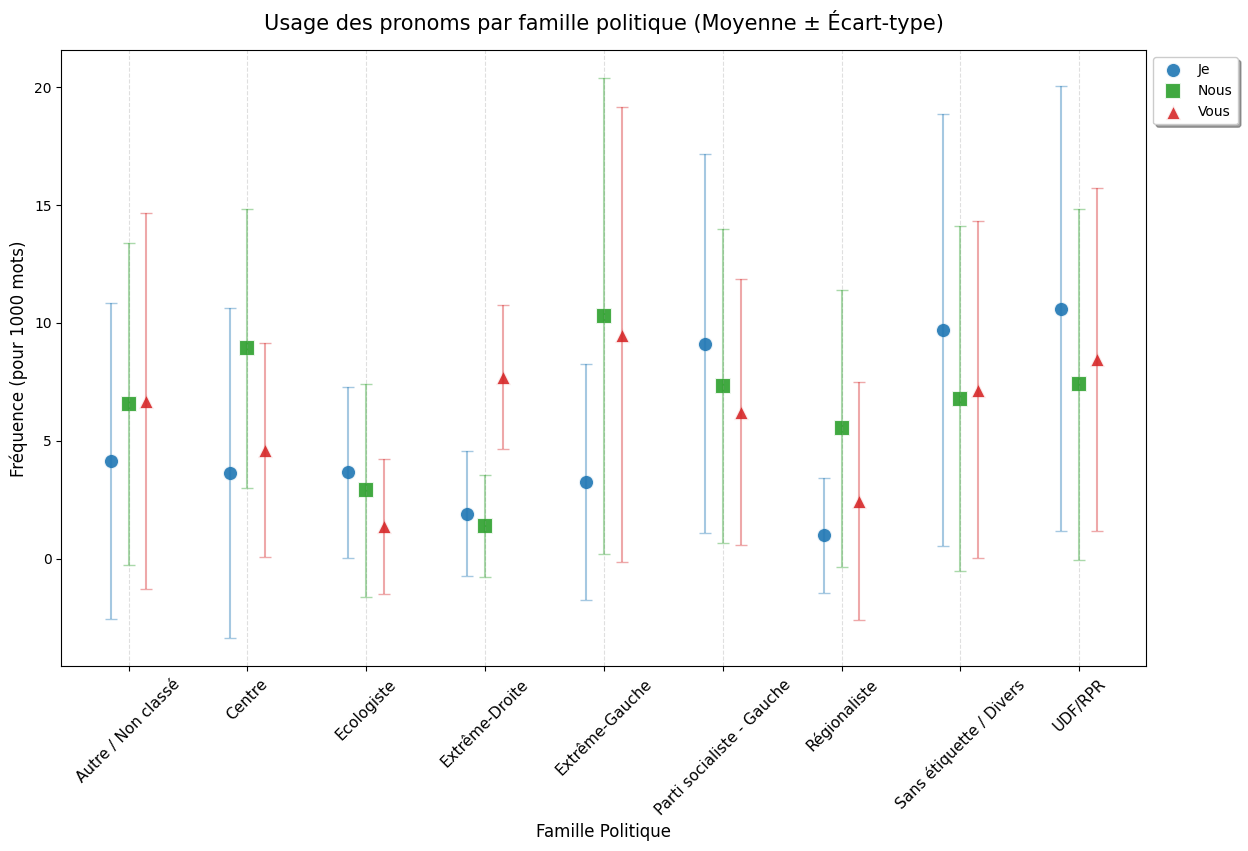

In [19]:
df = agg_stats.copy()
partis = df['parti_synthetique']
y_pos = np.arange(len(partis))  

plt.figure(figsize=(14, 8))

offset = 0.15 

plt.scatter(
    y_pos - offset, 
    df['je_p1000_mean'], 
    s=120,                # Taille des points
    c='#1f77b4',          # Couleur Bleu
    marker='o',           # Cercle
    label='Je', 
    edgecolors='white',   # Bordure blanche pour détacher du fond
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Je
plt.errorbar(y_pos - offset, df['je_p1000_mean'], yerr=df['je_p1000_std'], 
             fmt='none', ecolor='#1f77b4', alpha=0.4, capsize=4)

plt.scatter(
    y_pos, 
    df['nous_p1000_mean'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           # Carré
    label='Nous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Nous
plt.errorbar(y_pos, df['nous_p1000_mean'], yerr=df['nous_p1000_std'], 
             fmt='none', ecolor='#2ca02c', alpha=0.4, capsize=4)


plt.scatter(
    y_pos + offset, 
    df['vous_p1000_mean'], 
    s=120, 
    c='#d62728', 
    marker='^',           # Triangle
    label='Vous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Vous
plt.errorbar(y_pos + offset, df['vous_p1000_mean'], yerr=df['vous_p1000_std'], 
             fmt='none', ecolor='#d62728', alpha=0.4, capsize=4)

plt.title("Usage des pronoms par famille politique (Moyenne ± Écart-type)", fontsize=15, pad=15)
plt.xlabel("Famille Politique", fontsize=12)
plt.ylabel("Fréquence (pour 1000 mots)", fontsize=12)

# Remplacement des ticks numériques par les noms des partis
plt.xticks(y_pos, partis, fontsize=11, rotation = 45)

# Grille horizontale uniquement pour aider à lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Légende flottante pour ne pas gêner les points
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)


plt.show()

<b>Faire de meilleures stats desc !!! </b> 

Idées : étudier les verbes (actions/états) employés dans le discours.
Quelles fonctions ont les 'nous', les 'vous' dans la phrase ? (sujet, COD, autre)

### Identification de la fonction dans la phrase 

Les quelques cellules ci-dessous tentent d'identifier la fonction des pronoms 'je', 'nous', 'vous' lorsqu'ils sont utilisés (sujet VS objet), ainsi que le type de verbe qui les succède ou précède (action VS état).

In [20]:
# Verbes statifs
VERBES_ETAT = {'être', 'paraître', 'sembler', 'demeurer', 'rester', 'devenir', 'voir', 'vivre'
               'devoir', 'pouvoir', 'vouloir', 'falloir', 'savoir', 'croire', 'penser', 'appeler'}

VERBES_MODAUX = {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire', 'laisser', 'sembler', 'paraître'}


In [ ]:
# Prend environ 3-4 min 
textes = transcriptions['texte_nettoye'].tolist()

results = []

for doc in nlp.pipe(textes, batch_size=50, disable=["ner"]):
    
    stats = {'je': defaultdict(int), 'nous': defaultdict(int), 'vous': defaultdict(int)}
    mapping_pronom = {
        'je': ['je', "j'", 'moi', 'me', "m'"],
        'nous': ['nous'],
        'vous': ['vous']
    }

    for token in doc:
        if token.is_space or token.is_punct: 
            continue
        
        pronom_type = None
        if token.pos_ == "PRON":
            for p_type, formes in mapping_pronom.items():
                if token.text.lower() in formes or token.lemma_.lower() in formes:
                    pronom_type = p_type
                    break
        
        if pronom_type:
            verbe = None
            fonction = None
            
            if token.dep_ in ("nsubj", "nsubjpass"):
                fonction = "sujet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head
            elif token.dep_ in ("dobj", "obj", "iobj", "obl"):
                fonction = "objet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head

            lemme_tete = verbe_cible.lemma_.lower() # Ex type : Nous devons agir : on veut identifier agir et non devoir
            if lemme_tete in VERBES_MODAUX: # {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire'}
                for child in verbe_cible.children:
                    if child.pos_ == "VERB":
                        verbe = child # On remplace le modal par le verbe enfant
                        break
            else :
                verbe = verbe_cible
                
            if verbe:
                v_lem = verbe.lemma_.lower()
                type_v = "etat" if v_lem in VERBES_ETAT else "action"
                stats[pronom_type][f"{fonction}_{type_v}"] += 1
                stats[pronom_type][f"{fonction}"] +=1
                stats[pronom_type][f"{type_v}"] +=1

    row = {}
    for p in ['je', 'nous', 'vous']:
        for k, v in stats[p].items():
            row[f"{p}_{k}"] = v
    
    for p in ['je', 'nous', 'vous']:
        for f in ['sujet', 'objet']:
            for t in ['action', 'etat']:
                key = f"{p}_{f}_{t}"
                if key not in row: 
                    row[key] = 0
                
    results.append(row)

df_structure = pd.DataFrame(results)

# Concaténation avec les infos originales
transcriptions_structure_test = pd.concat([transcriptions[['id', 'parti_synthetique']], df_structure], axis=1)

In [22]:
transcriptions_structure_test.columns

Index(['id', 'parti_synthetique', 'je_objet_action', 'je_objet', 'je_action',
       'je_sujet_action', 'je_sujet', 'je_None_action', 'je_None',
       'nous_sujet_action', 'nous_sujet', 'nous_action', 'nous_None_action',
       'nous_None', 'vous_sujet_action', 'vous_sujet', 'vous_action',
       'vous_objet_action', 'vous_objet', 'vous_sujet_etat', 'vous_etat',
       'vous_None_action', 'vous_None', 'je_sujet_etat', 'je_objet_etat',
       'nous_sujet_etat', 'nous_objet_action', 'nous_objet_etat',
       'vous_objet_etat', 'je_etat', 'vous_None_etat', 'nous_etat',
       'nous_objet', 'je_None_etat', 'nous_None_etat'],
      dtype='object')

In [23]:
cols_scores = ['je_objet_action', 'je_objet', 'je_action',
       'je_sujet_action', 'je_sujet', 'je_None_action', 'je_None',
       'nous_sujet_action', 'nous_sujet', 'nous_action', 'nous_None_action',
       'nous_None', 'vous_sujet_action', 'vous_sujet', 'vous_action',
       'vous_objet_action', 'vous_objet', 'vous_sujet_etat', 'vous_etat',
       'vous_None_action', 'vous_None', 'je_sujet_etat', 'je_objet_etat',
       'nous_sujet_etat', 'nous_objet_action', 'nous_objet_etat',
       'vous_objet_etat', 'je_etat', 'vous_None_etat', 'nous_etat',
       'nous_objet', 'je_None_etat', 'nous_None_etat']  # A CHANGER

agg_stats = transcriptions_structure_test.groupby('parti_synthetique')[cols_scores].agg(['sum']).reset_index()
agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

In [24]:
agg_stats

,parti_synthetique,je_objet_action_sum,je_objet_sum,je_action_sum,je_sujet_action_sum,je_sujet_sum,je_None_action_sum,je_None_sum,nous_sujet_action_sum,nous_sujet_sum,...,nous_sujet_etat_sum,nous_objet_action_sum,nous_objet_etat_sum,vous_objet_etat_sum,je_etat_sum,vous_None_etat_sum,nous_etat_sum,nous_objet_sum,je_None_etat_sum,nous_None_etat_sum
0,Autre / Non classé,78,80.0,738.0,479,549.0,181.0,195.0,977,1083.0,...,106,151,22,0,86.0,37.0,144.0,173.0,14.0,16.0
1,Centre,28,28.0,284.0,195,219.0,61.0,66.0,163,220.0,...,57,34,10,0,29.0,8.0,80.0,44.0,5.0,13.0
2,Ecologiste,108,108.0,1659.0,1307,1469.0,244.0,258.0,1356,1491.0,...,135,182,71,5,176.0,25.0,224.0,253.0,14.0,18.0
3,Extrême-Droite,32,32.0,925.0,779,845.0,114.0,117.0,592,615.0,...,23,39,0,6,69.0,80.0,28.0,39.0,3.0,5.0
4,Extrême-Gauche,302,306.0,2193.0,1535,1836.0,356.0,414.0,4535,5427.0,...,892,2232,251,49,363.0,148.0,1188.0,2483.0,58.0,45.0
5,Parti socialiste - Gauche,300,303.0,3092.0,2210,2515.0,582.0,612.0,1367,1582.0,...,215,184,67,19,338.0,78.0,316.0,251.0,30.0,34.0
6,Régionaliste,2,2.0,12.0,7,11.0,3.0,3.0,70,77.0,...,7,7,1,1,4.0,0.0,8.0,8.0,0.0,0.0
7,Sans étiquette / Divers,949,960.0,6898.0,4774,5517.0,1175.0,1264.0,2691,3099.0,...,408,578,96,53,843.0,141.0,575.0,674.0,89.0,71.0
8,UDF/RPR,741,751.0,5045.0,3355,3832.0,949.0,1001.0,2159,2362.0,...,203,415,79,31,539.0,75.0,318.0,494.0,52.0,36.0


Statistiques descriptives (<b> A FAIRE ! </b>)

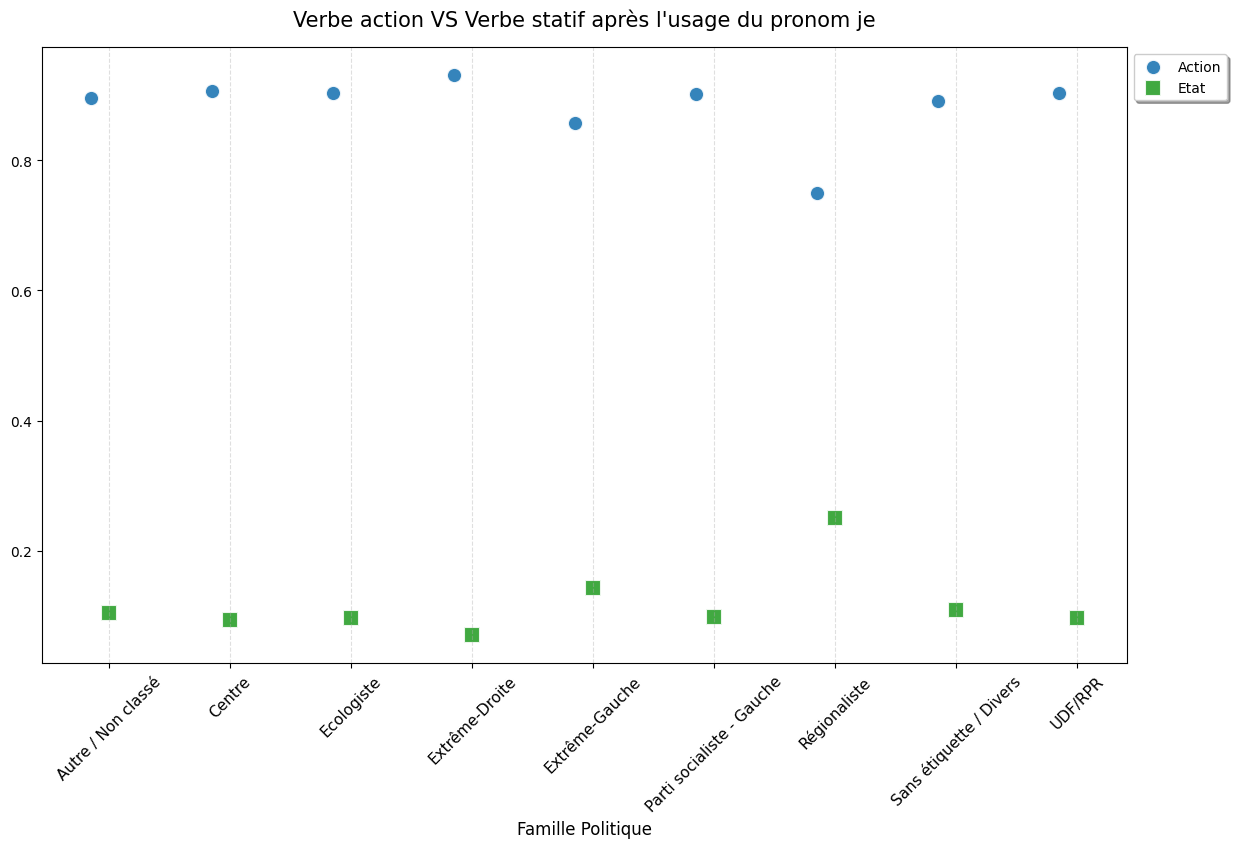

In [25]:
# Je action VS je etat

df = agg_stats[['parti_synthetique', 'je_action_sum', 'je_etat_sum']].copy()
df['prop_je_action'] = df['je_action_sum']/(df['je_action_sum']+df['je_etat_sum'])
df['prop_je_etat'] = 1- df['prop_je_action']
partis = df['parti_synthetique']
y_pos = np.arange(len(partis))  

plt.figure(figsize=(14, 8))

offset = 0.15 

plt.scatter(
    y_pos - offset, 
    df['prop_je_action'], 
    s=120,                # Taille des points
    c='#1f77b4',          # Couleur Bleu
    marker='o',           # Cercle
    label='Action', 
    edgecolors='white',   # Bordure blanche pour détacher du fond
    linewidth=1.5,
    alpha=0.9
)

plt.scatter(
    y_pos, 
    df['prop_je_etat'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           # Carré
    label='Etat', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)

plt.title("Verbe action VS Verbe statif après l'usage du pronom je", fontsize=15, pad=15)
plt.xlabel("Famille Politique", fontsize=12)

# Remplacement des ticks numériques par les noms des partis
plt.xticks(y_pos, partis, fontsize=11, rotation = 45)

# Grille horizontale uniquement pour aider à lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Légende flottante pour ne pas gêner les points
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)


plt.show()

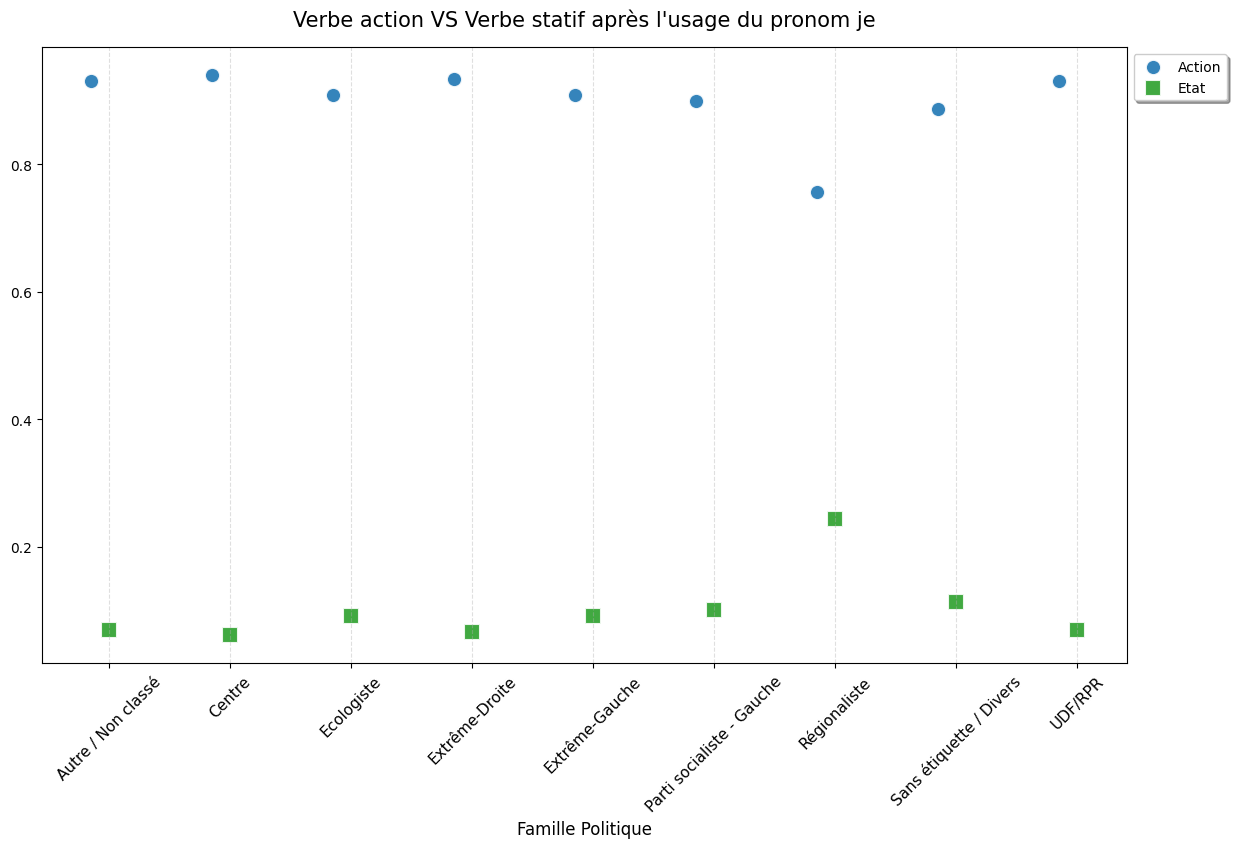

In [26]:
df = agg_stats[['parti_synthetique', 'vous_action_sum', 'vous_etat_sum']].copy()
df['prop_vous_action'] = df['vous_action_sum']/(df['vous_action_sum']+df['vous_etat_sum'])
df['prop_vous_etat'] = 1- df['prop_vous_action']
partis = df['parti_synthetique']
y_pos = np.arange(len(partis))  

plt.figure(figsize=(14, 8))

offset = 0.15 

plt.scatter(
    y_pos - offset, 
    df['prop_vous_action'], 
    s=120,                # Taille des points
    c='#1f77b4',          # Couleur Bleu
    marker='o',           # Cercle
    label='Action', 
    edgecolors='white',   # Bordure blanche pour détacher du fond
    linewidth=1.5,
    alpha=0.9
)

plt.scatter(
    y_pos, 
    df['prop_vous_etat'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           # Carré
    label='Etat', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)

plt.title("Verbe action VS Verbe statif après l'usage du pronom je", fontsize=15, pad=15)
plt.xlabel("Famille Politique", fontsize=12)

# Remplacement des ticks numériques par les noms des partis
plt.xticks(y_pos, partis, fontsize=11, rotation = 45)

# Grille horizontale uniquement pour aider à lire les valeurs
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Légende flottante pour ne pas gêner les points
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)


plt.show()

C'est pas hyper instructif. Il faut regarder aussi la place dans la phrase. 

### Echantillonnage de phrases à annoter

In [27]:
PRONOMS_CIBLES = {'je', 'nous', 'vous', "j'", "m'"}

def segmenter_et_extraire_features(texte_long):
    """
    Découpe un texte en phrases et identifie celles dans lesquelles apparaît un des pronoms cibles.
    Retourne une liste de dictionnaires : {'texte': phrase, 'doc_id': id}
    """
    doc = nlp(texte_long)
    phrases_interessantes = []
    
    for sent in doc.sents:
            
        sent_text = sent.text.strip()
        has_pronom = False
        pronoms_in_sent = []
        
        for token in sent:
            t_lower = token.text.lower()
            l_lower = token.lemma_.lower()
            
            if t_lower in PRONOMS_CIBLES and token.pos_ == "PRON":
                has_pronom = True
                pronoms_in_sent.append(t_lower)
            
            if has_pronom : 
                phrases_interessantes.append({
                    "texte": sent_text,
                    "pronoms": pronoms_in_sent
                })
                
    return phrases_interessantes


In [28]:
len(transcriptions['texte_nettoye'])

5936

In [29]:
sample_texts = transcriptions[['texte_nettoye', 'id']].sample(n = 1000)

print("Segmentation des textes en phrases...")
toutes_les_phrases = []

for idx, texte in sample_texts['texte_nettoye'].items():
    if isinstance(texte, str) and len(texte) > 10:
        phrases = segmenter_et_extraire_features(texte)
        id_text = sample_texts['id'][idx]
        for p in phrases:
            p['doc_id'] = id_text
        toutes_les_phrases.extend(phrases)

print(f"Total de phrases candidates extraites : {len(toutes_les_phrases)}")


Segmentation des textes en phrases...
Total de phrases candidates extraites : 151893


In [30]:
echantillon_final = []

list_je = [p for p in toutes_les_phrases if ('je' in p['pronoms'] or "j'" in p['pronoms'] )]

list_nous = [p for p in toutes_les_phrases if 'nous' in p['pronoms']]

list_vous = [p for p in toutes_les_phrases if 'vous' in p['pronoms'] ]

print("Je :", len(list_je))
print("Vous : ", len(list_vous))
print("Nous : ", len(list_nous))

Je : 59534
Vous :  59748
Nous :  68032


In [31]:
import random 
random.shuffle(list_je)
echantillon_final.extend(list_je[:300])

random.shuffle(list_nous)
echantillon_final.extend([p for p in list_nous if p not in echantillon_final][:300])

random.shuffle(list_vous)
echantillon_final.extend([p for p in list_vous if p not in echantillon_final][:300])

print(f"Taille de l'échantillon final à annoter : {len(echantillon_final)} phrases.")

Taille de l'échantillon final à annoter : 900 phrases.


In [33]:
echantillon_final

[{'texte': "je pense également nécessaire qu'un plus grand nombre de femmes participent à l'élaboration des décisions aussi importantes que celles qui engagent la vie de nos familles",
  'pronoms': ['je'],
  'doc_id': 'EL197_L_1993_03_091_08_1_PF_09'},
 {'texte': "pour notre circonscription d'abord en toute modestie, je pense m'être acquitté consciencieusement et avec probité du mandat que vous m'avez confié, le 12 juin 1988 : des résultats nombreux et divers l'attestent, que j'ai évoqués dans mon journal de campagne.",
  'pronoms': ['je', "m'", 'vous', "m'", "j'"],
  'doc_id': 'EL189_L_1993_03_007_03_1_PF_03'},
 {'texte': "je vous en remercie chaleureusement et cela m'encourage à persévérer dans notre action.",
  'pronoms': ['je', 'vous', "m'"],
  'doc_id': 'EL191_L_1993_03_033_09_2_PF_01'},
 {'texte': "- législatives mars 93 : considérant que la légitimité des électeurs vaut plus que celle d'un parti politique et refusant toute combine politicienne, parce que j'ai le courage de mes o

In [38]:
# A MODIFIER
# On pré-annote les données, comme ça on n'aura plus qu'à repasser dessus, corriger et compléter.
def phrase_vers_lignes_tokens(phrase_data, phrase_id):
    '''
    phrases_data : dictionnaire contenant l'ensemble des phrases à annoter (sous la clé texte).
    Retourne une liste de dictionnaires avec des suggestions d'annotations
    '''
    texte = phrase_data['texte']
    doc = nlp(texte)
    rows = []
    
    verbe_types = {} # ACT/ETAT
    pronoms_roles = {} # SUJ/OBJ
    
    for token in doc:
        t_lower = token.text.lower()
        l_lower = token.lemma_.lower()
        
        # Rôle du pronom dans la hrase
        if t_lower in PRONOMS_CIBLES and token.pos_ == "PRON":
            if token.dep_ in ("nsubj", "nsubjpass"):
                pronoms_roles[token.i] = "SUJ"
            elif token.dep_ in ("dobj", "obj", "iobj", "obl"):
                pronoms_roles[token.i] = "OBJ"
        
        # Type de verbe
        if token.pos_ in ("VERB", "AUX"):

            is_modal = l_lower in VERBES_MODAUX  # True/False
            
            if is_modal:
                for child in token.children:  # On cherche si on a un verbe parmi les enfants (penser à 'nous devons agir')
                    if child.pos_ == "VERB":
                        child_lemme = child.lemma_.lower()
                        child_is_etat_bool = child_lemme in VERBES_ETAT
                        verbe_types[child.i] = "ETAT" if child_is_etat_bool else "ACT"
                
            else:
                is_etat_bool = l_lower in VERBES_ETAT
                verbe_types[token.i] = "ETAT" if is_etat_bool else "ACT"

    # Construction des lignes
    for token in doc:
        label_suggere = "O"
        
        if token.i in pronoms_roles:
            label_suggere = f"B-PRON_{pronoms_roles[token.i]}"
        
        if token.i in verbe_types:
            if label_suggere == "O":
                label_suggere = f"B-VERB_{verbe_types[token.i]}"
        
        rows.append({
            "phrase_id" : phrase_id,
            "doc_id_origine": phrase_data['doc_id'],
            "pronoms": phrase_data['pronoms'],
            "token_text": token.text,
            "lemma": token.lemma_,
            "pos": token.pos_,
            "dep": token.dep_,
            "suggestion_label": label_suggere,
            "label_final": "" 
        })
        
    return rows

In [39]:
# Génération du fichier à annoter

rows_csv = []
for i, phrase_data in enumerate(echantillon_final):
    rows = phrase_vers_lignes_tokens(phrase_data, i)
    rows_csv.extend(rows)

annotate_csv = pd.DataFrame(rows_csv)

annotate_csv.to_csv("annotation_token_strategy.csv", index=False, encoding="utf-8")

print("\nAperçu des 10 premières lignes :")
print(annotate_csv[['token_text', 'suggestion_label', 'label_final']].head(10))


Aperçu des 10 premières lignes :
   token_text suggestion_label label_final
0          je       B-PRON_SUJ            
1       pense      B-VERB_ETAT            
2   également                O            
3  nécessaire                O            
4         qu'                O            
5          un                O            
6        plus                O            
7       grand                O            
8      nombre                O            
9          de                O            
